## EDA and First Logistic Regression Results

In [1]:
import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

from src.models import get_logistic_regression
from src.preprocessing import (
    BINARY_COLS,
    CATEGORICAL_COLS,
    NUMERIC_COLS,
    TARGET_COL,
    build_logreg_pipeline,
    load_data,
    stratified_split,
)

sns.set_theme(style="whitegrid")
df = load_data()
df.shape

(4424, 35)

### 1. Missing Values

In [2]:
df.isna().sum().sum() # check for missing values

np.int64(0)

### 2. Target class balance

Target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64


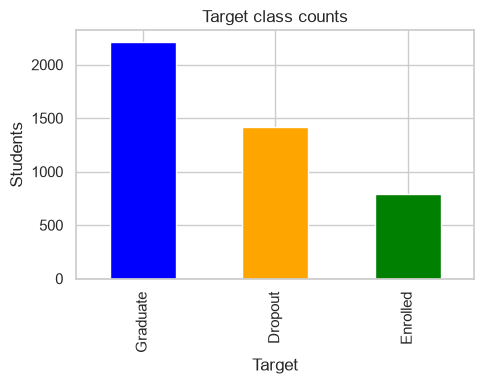

In [3]:
counts = df[TARGET_COL].value_counts()
proportions = df[TARGET_COL].value_counts(normalize=True).round(3)
print(proportions)

fig, ax = plt.subplots(figsize=(5, 4))
counts.plot(kind = "bar", ax=ax, color = ["blue", "orange", "green"])
ax.set_title("Target class counts")
ax.set_ylabel("Students")
plt.tight_layout()
plt.show()

# notice the imbalance in the target classes
# 50% Graduate, 32% Dropout, 18% Enrolled
# this is why the modeling step uses class_weight='balanced' 
# otherwise, a model could hit about 70% accuracy by predicting the majority class (Graduate)

### 3. Key numeric variables vs. Target

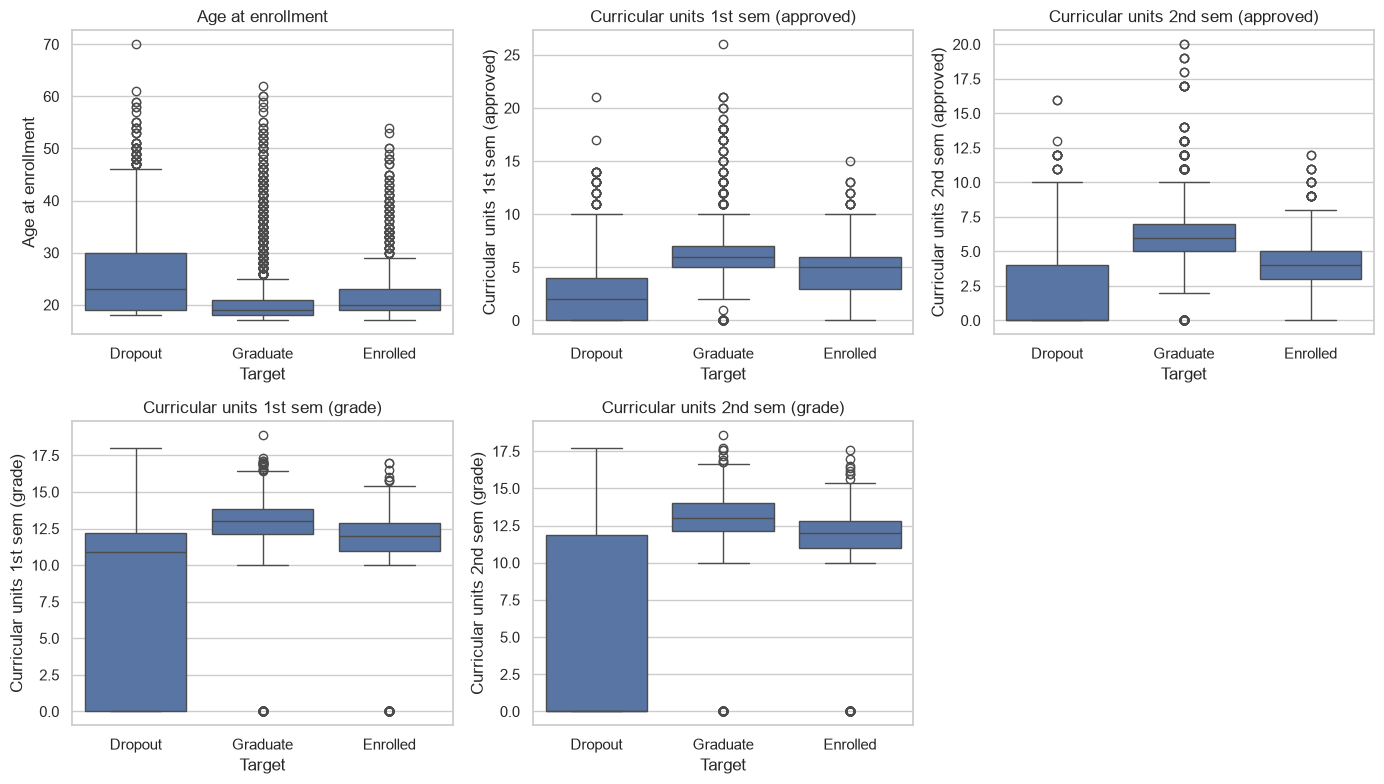

In [4]:
key_numeric_cols = [
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (grade)",
]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 8))
for ax, col in zip(axes.flat, key_numeric_cols):
    sns.boxplot(data=df, x=TARGET_COL, y=col, ax=ax)
    ax.set_title(col)
axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()



### 4. Key categorical/binary variables vs. Target

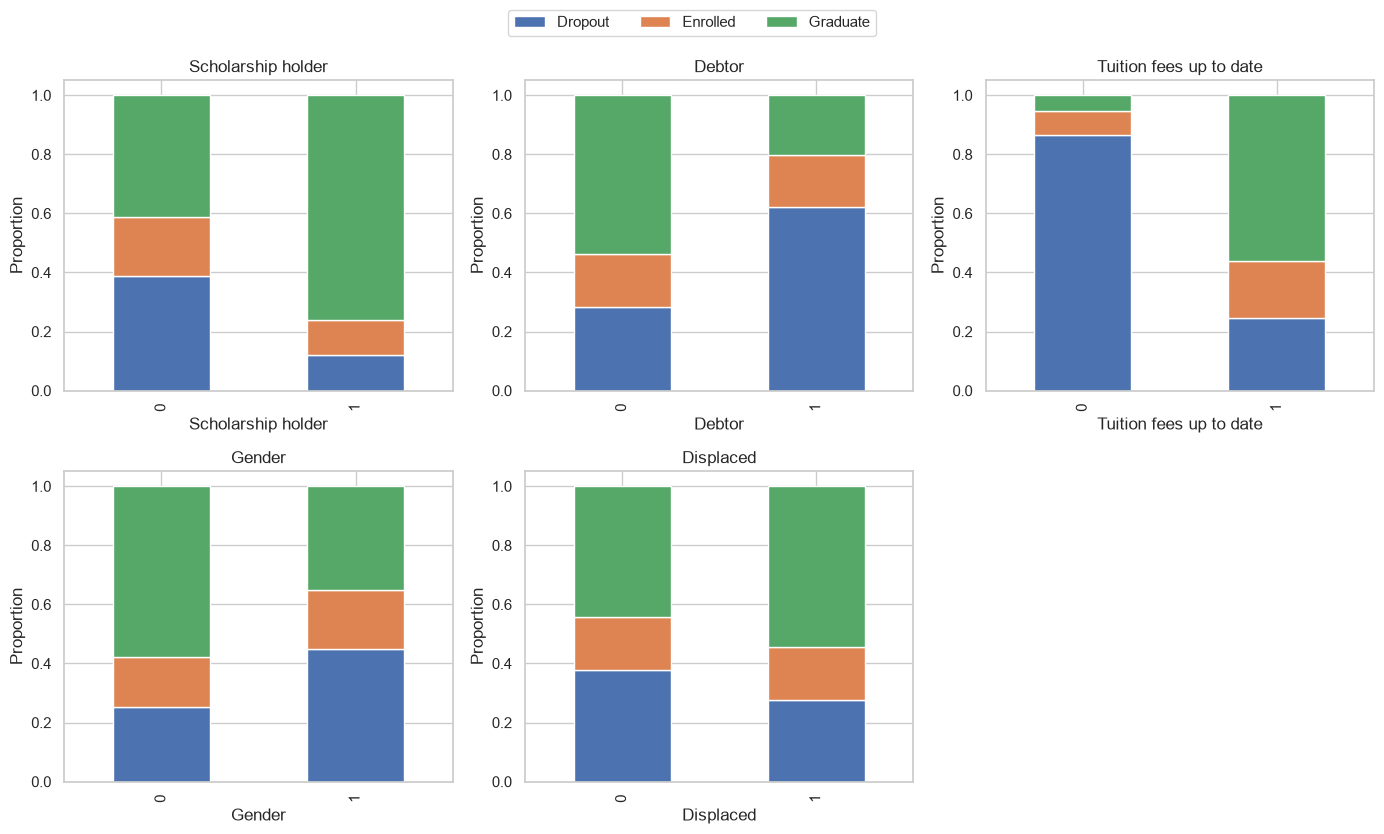

In [5]:
key_categorical_cols = ["Scholarship holder", "Debtor", "Tuition fees up to date", "Gender", "Displaced"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, key_categorical_cols):
    rates = pd.crosstab(df[col], df[TARGET_COL], normalize="index")
    rates.plot(kind="bar", stacked=True, ax=ax, legend=False)
    ax.set_title(col)
    ax.set_ylabel("Proportion")
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.05))
axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()


### 5. Collinearity check: parental variables

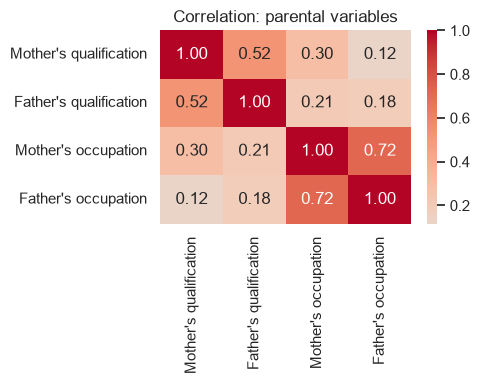

In [6]:
parent_education_cols = ["Mother's qualification", "Father's qualification",
               "Mother's occupation", "Father's occupation"]

corr = df[parent_education_cols].corr()
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation: parental variables")
plt.tight_layout()
plt.show()


### 6. Full numeric correlation heatmap

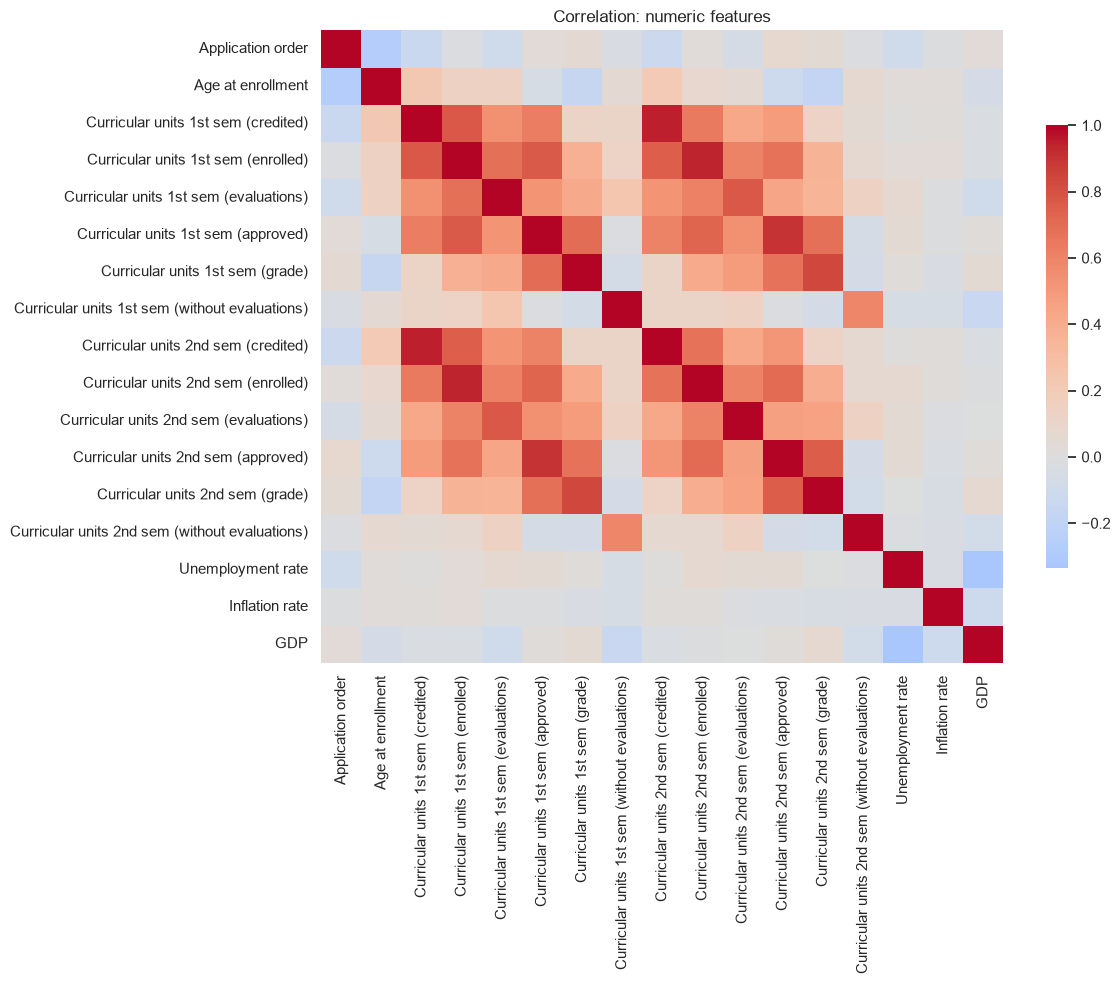

In [7]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df[NUMERIC_COLS].corr(), cmap="coolwarm", center=0, ax=ax, cbar_kws={"shrink": 0.7})
ax.set_title("Correlation: numeric features")
plt.tight_layout()
plt.show()

### 7. First Logistic Regression Baseline

In [8]:
X_train, X_test, y_train, y_test = stratified_split(df)

print("Train class balance:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest class balance:")
print(y_test.value_counts(normalize=True).round(3))

pipe = build_logreg_pipeline(get_logistic_regression())
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print(classification_report(y_test, y_pred))

Train class balance:
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64

Test class balance:
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.180
Name: proportion, dtype: float64
              precision    recall  f1-score   support

     Dropout       0.81      0.69      0.75       284
    Enrolled       0.41      0.62      0.49       159
    Graduate       0.86      0.78      0.82       442

    accuracy                           0.72       885
   macro avg       0.69      0.70      0.69       885
weighted avg       0.76      0.72      0.74       885



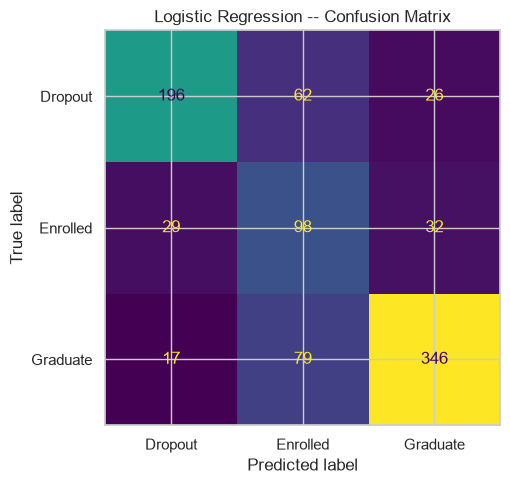

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
ax.set_title("Logistic Regression -- Confusion Matrix")
plt.tight_layout()
plt.show()